# Mumbai Flood Vulnerability Assessment: Initial Data Exploration

This notebook explores the currently available data for the Mumbai Flood Vulnerability Assessment project, focusing on the data that has been successfully collected: administrative boundaries, elevation data (DEM), and infrastructure data.

## Setup and Imports



In [1]:
# Mumbai Administrative Boundaries Exploration with Census Integration

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
from shapely.geometry import mapping, Point
import seaborn as sns
from pathlib import Path
import contextily as ctx

# Set matplotlib style
plt.style.use('ggplot')
%matplotlib inline



## 1. Administrative Boundaries

Let's first examine the Mumbai boundary data:





Census Data:
Number of records: 97
Wards: 24

Census Summary by Ward:
  Ward Name  Total Population  Total Males  Total Females  SC Population  \
0         A            185014       101227          83787          13634   
1         B            127290        70445          56845           5338   
2         C            166161        98027          68134           2308   
3         D            346866       182988         163878          16844   
4         E            393286       216067         177219          22214   

   ST Population  Gender Ratio  SC Percentage  ST Percentage  
0           3193    827.713950       7.369172       1.725815  
1           1089    806.941586       4.193574       0.855527  
2            378    695.053404       1.389014       0.227490  
3           1629    895.566922       4.856054       0.469634  
4           2607    820.203918       5.648307       0.662876  
Census summary saved to visualizations/mumbai_census_summary.csv


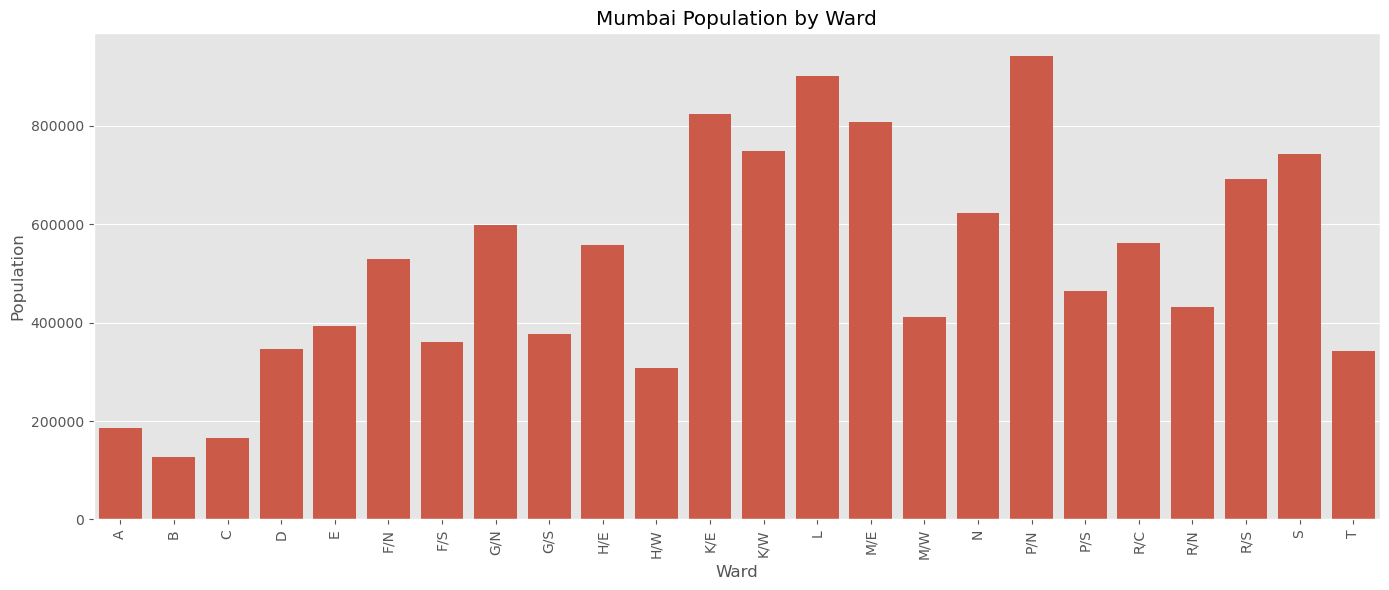

In [2]:
# Create output directory for saving figures
output_dir = Path("visualizations")
output_dir.mkdir(exist_ok=True)

## 1. Load Census Data for Integration

# Load the Mumbai census data 
census_file = Path("data/raw/census/mumbai-census.csv")
if census_file.exists():
    census_data = pd.read_csv(census_file)
    print("Census Data:")
    print(f"Number of records: {len(census_data)}")
    print(f"Wards: {census_data['Ward Name'].nunique()}")
    
    # Create a summary by ward
    census_summary = census_data.groupby('Ward Name').agg({
        'Total Population': 'sum',
        'Total Males': 'sum',
        'Total Females': 'sum',
        'SC Population': 'sum',
        'ST Population': 'sum'
    }).reset_index()
    
    # Calculate gender ratio and SC/ST percentage
    census_summary['Gender Ratio'] = census_summary['Total Females'] / census_summary['Total Males'] * 1000
    census_summary['SC Percentage'] = census_summary['SC Population'] / census_summary['Total Population'] * 100
    census_summary['ST Percentage'] = census_summary['ST Population'] / census_summary['Total Population'] * 100
    
    print("\nCensus Summary by Ward:")
    print(census_summary.head())
    
    # Save the census summary
    census_summary.to_csv(output_dir / "mumbai_census_summary.csv", index=False)
    print(f"Census summary saved to {output_dir / 'mumbai_census_summary.csv'}")
    
    # Plot total population by ward
    plt.figure(figsize=(14, 6))
    sns.barplot(x='Ward Name', y='Total Population', data=census_summary)
    plt.title("Mumbai Population by Ward")
    plt.xlabel("Ward")
    plt.ylabel("Population")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(output_dir / "census_population_by_ward.png", dpi=300)
    plt.show()
else:
    print(f"Census file not found: {census_file}")
    census_data = None
    census_summary = None




Mumbai Administrative Boundary:
CRS: EPSG:4326
Geometry type: ['Polygon' 'MultiPolygon']
Number of districts: 2

Columns:
- GID_2
- GID_0
- COUNTRY
- GID_1
- NAME_1
- NL_NAME_1
- NAME_2
- VARNAME_2
- NL_NAME_2
- TYPE_2
- ENGTYPE_2
- CC_2
- HASC_2
- geometry

Districts included:
- Mumbai City (IND.20.17_1)
- Mumbai Suburban (IND.20.18_1)

Total area: 480.31 sq km


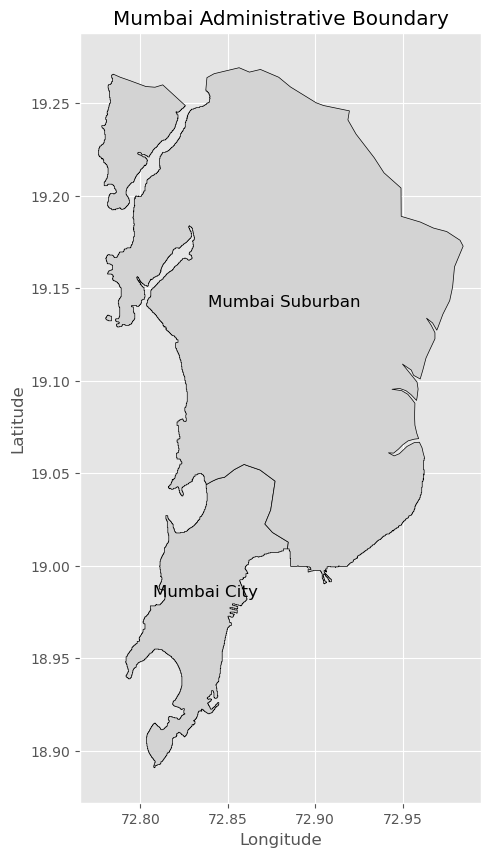

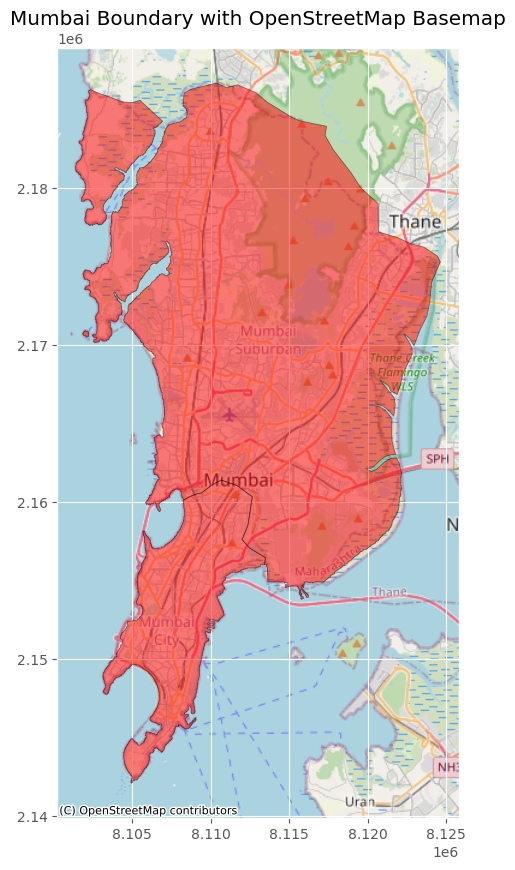

In [3]:
## 2. Load and Analyze Mumbai Administrative Boundaries

# Define paths
boundary_dir = Path("data/raw/boundaries")
mumbai_boundary_file = boundary_dir / "mumbai_boundary.shp"
mumbai_wards_file = boundary_dir / "mumbai_wards.shp"

# Load Mumbai boundary from GADM data
if not mumbai_boundary_file.exists():
    # Extract Mumbai boundary if it doesn't exist
    gadm_level2 = boundary_dir / "gadm41_IND_2.shp"  # Level 2 contains districts
    
    if gadm_level2.exists():
        print("GADM Level 2 file exists. Extracting Mumbai boundary...")
        # Load GADM Level 2 data (districts)
        districts = gpd.read_file(gadm_level2)
        
        # Filter for Mumbai (includes Mumbai, Mumbai Suburban)
        print("Available districts in Maharashtra:")
        maharashtra_districts = districts[districts['NAME_1'] == 'Maharashtra']
        print(maharashtra_districts['NAME_2'].unique())
        
        # Filter for Mumbai districts
        mumbai_districts = maharashtra_districts[
            maharashtra_districts['NAME_2'].str.contains('Mumbai', case=False, na=False)]
        
        if len(mumbai_districts) > 0:
            print(f"Found {len(mumbai_districts)} Mumbai districts")
            # Save Mumbai boundaries
            mumbai_districts.to_file(mumbai_boundary_file)
            print(f"Mumbai boundaries saved to {mumbai_boundary_file}")
        else:
            print("No Mumbai districts found in GADM data. Check filtering criteria.")
    else:
        print(f"GADM Level 2 file not found at {gadm_level2}")
        print("Please download GADM data or run the download_boundaries.py script.")

# Load and analyze Mumbai boundary
if mumbai_boundary_file.exists():
    # Load Mumbai boundary
    mumbai = gpd.read_file(mumbai_boundary_file)
    
    # Print basic information
    print("\nMumbai Administrative Boundary:")
    print(f"CRS: {mumbai.crs}")
    print(f"Geometry type: {mumbai.geometry.geom_type.unique()}")
    print(f"Number of districts: {len(mumbai)}")
    print("\nColumns:")
    for col in mumbai.columns:
        print(f"- {col}")
    
    # Print district names
    print("\nDistricts included:")
    if 'NAME_2' in mumbai.columns:
        for idx, row in mumbai.iterrows():
            print(f"- {row['NAME_2']} ({row['GID_2']})")
    
    # Calculate total area
    mumbai_utm = mumbai.to_crs(epsg=32643)  # UTM Zone 43N for accurate area calculation
    total_area_sqkm = mumbai_utm.area.sum() / 1_000_000  # Convert from sq m to sq km
    print(f"\nTotal area: {total_area_sqkm:.2f} sq km")
    
    # Plot Mumbai boundary
    fig, ax = plt.subplots(figsize=(12, 10))
    mumbai.plot(ax=ax, color='lightgrey', edgecolor='black')
    
    # Add district labels if we have multiple districts
    if len(mumbai) > 1 and 'NAME_2' in mumbai.columns:
        for idx, row in mumbai.iterrows():
            centroid = row.geometry.centroid
            ax.text(centroid.x, centroid.y, row['NAME_2'], fontsize=12, 
                   ha='center', va='center', color='black')
    
    ax.set_title("Mumbai Administrative Boundary")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.savefig(output_dir / "mumbai_boundary.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Plot with basemap for context
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Convert to Web Mercator for contextily
    mumbai_web = mumbai.to_crs(epsg=3857)
    mumbai_web.plot(ax=ax, color='red', alpha=0.5, edgecolor='black')
    
    # Add OpenStreetMap basemap
    try:
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
        plt.title("Mumbai Boundary with OpenStreetMap Basemap")
        plt.savefig(output_dir / "mumbai_boundary_with_basemap.png", dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Error adding basemap: {e}")
        print("Install contextily with: pip install contextily")
else:
    print(f"Mumbai boundary file not found: {mumbai_boundary_file}")
    print("Please run the extract_mumbai_boundaries.py script first.")
    mumbai = None




Now let's look for ward boundaries:





Mumbai Wards:
CRS: EPSG:4326
Number of wards: 7

Columns:
- GID_3
- GID_0
- COUNTRY
- GID_1
- NAME_1
- NL_NAME_1
- GID_2
- NAME_2
- NL_NAME_2
- NAME_3
- VARNAME_3
- NL_NAME_3
- TYPE_3
- ENGTYPE_3
- CC_3
- HASC_3
- ward_id
- geometry

Total area (from wards): 480.31 sq km
Average ward size: 68.62 sq km
Smallest ward: 0.09 sq km
Largest ward: 136.14 sq km

Integrating census data with ward boundaries...
Using positional matching for remaining wards...


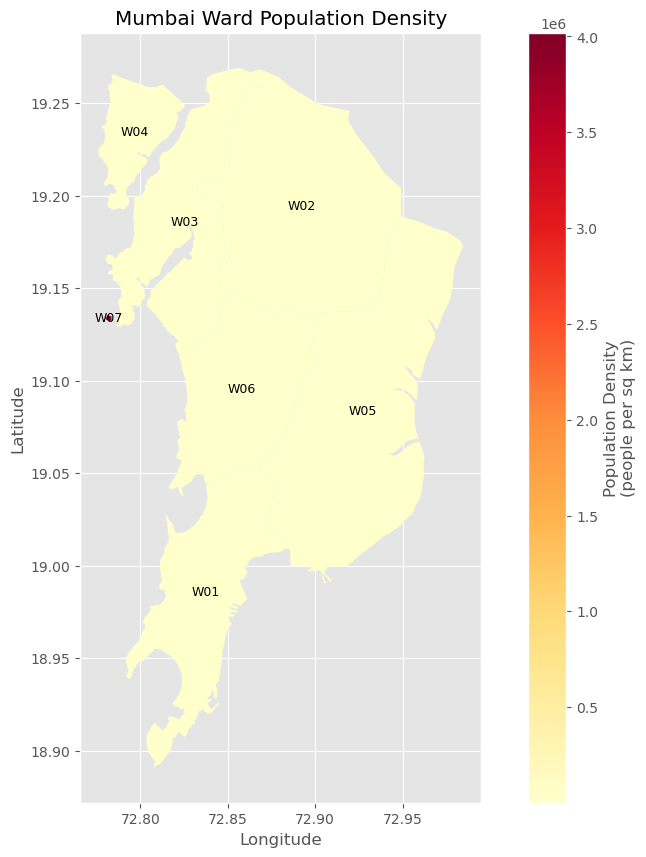

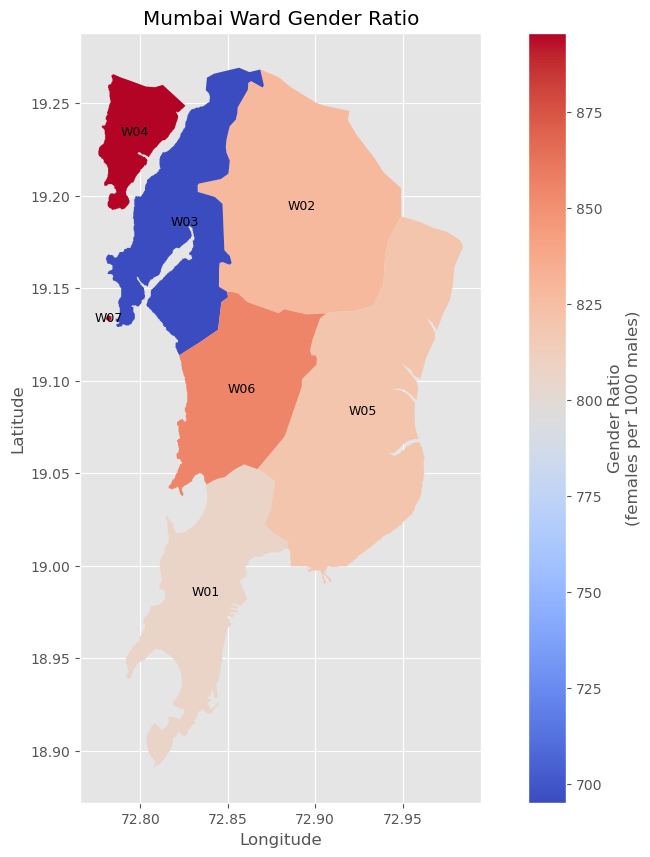

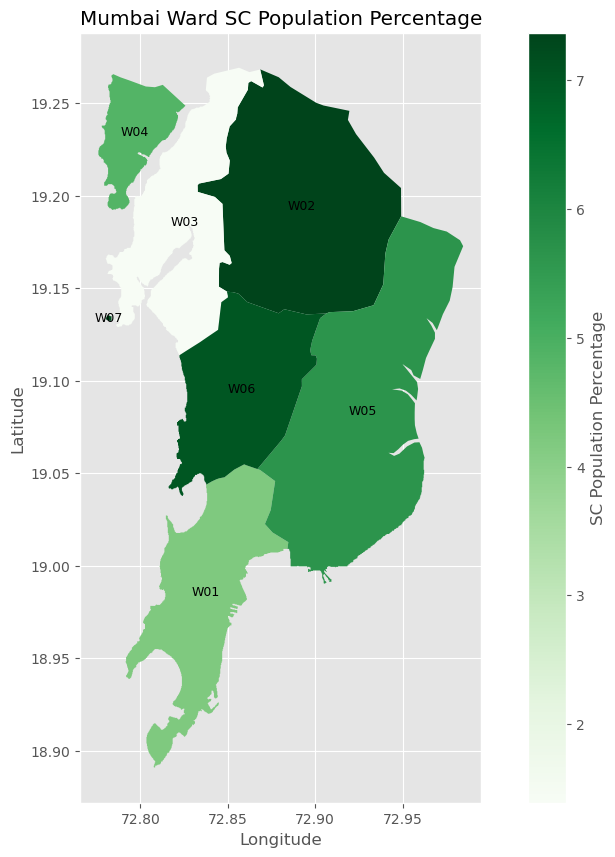

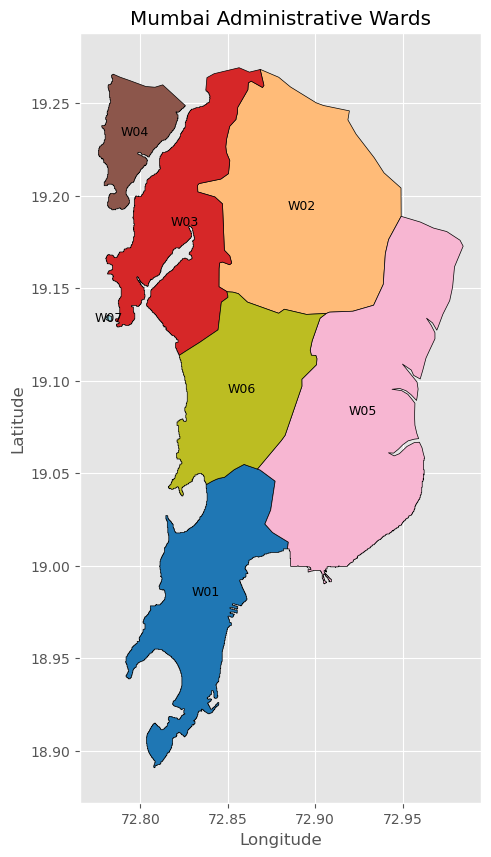

NameError: name 'withStroke' is not defined

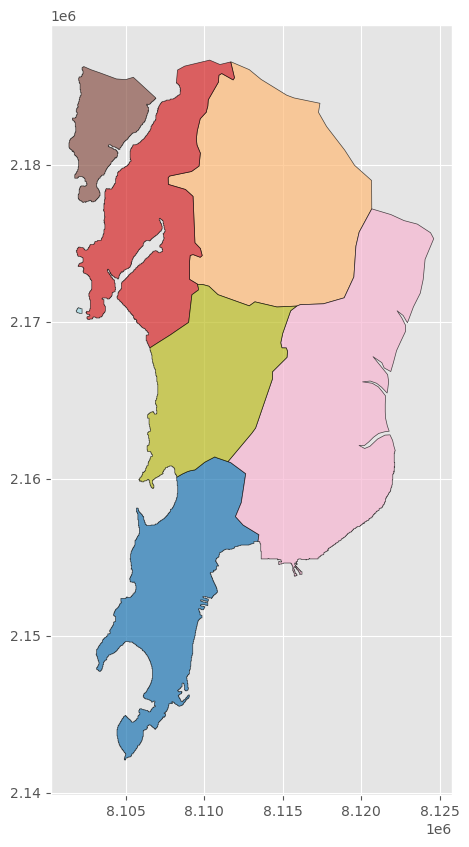

In [4]:
## 3. Analyze Ward Boundaries and Integrate with Census Data

# Check for ward boundaries or create from census data if missing
if not mumbai_wards_file.exists() and census_data is not None and mumbai is not None:
    print("Ward file not found. Creating ward boundaries from census data...")
    
    # Create ward boundaries based on census data
    # This is a simplified approach - in a real project, you'd need more accurate boundaries
    
    # Get the unique ward names from census
    ward_names = census_data['Ward Name'].unique()
    print(f"Found {len(ward_names)} ward names in census data")
    
    # Create approximate ward boundaries
    # Simplified approach: divide each district roughly by the number of wards
    wards_list = []
    
    for idx, district in mumbai.iterrows():
        district_name = district['NAME_2'] if 'NAME_2' in mumbai.columns else f"District_{idx}"
        district_geom = district.geometry
        
        # Roughly determine wards in this district based on naming convention
        if district_name == "Mumbai":
            # Wards A-G/S might be in Mumbai district
            district_wards = [w for w in ward_names if w[0] in "ABCDEFG"]
        else:  # Mumbai Suburban
            # Other wards might be in Mumbai Suburban
            district_wards = [w for w in ward_names if w[0] not in "ABCDEFG"]
        
        print(f"District {district_name} approximately has {len(district_wards)} wards")
        
        if len(district_wards) == 0:
            # If no wards matched, split evenly
            district_wards = [f"Ward_{i+1}" for i in range(len(ward_names) // len(mumbai))]
        
        # Create a simple grid of wards within the district
        grid_size = int(np.ceil(np.sqrt(len(district_wards))))
        bounds = district_geom.bounds
        width = bounds[2] - bounds[0]
        height = bounds[3] - bounds[1]
        
        # Create cells
        for i, ward_name in enumerate(district_wards):
            row = i // grid_size
            col = i % grid_size
            
            x_min = bounds[0] + col * (width / grid_size)
            y_min = bounds[1] + row * (height / grid_size)
            x_max = bounds[0] + (col + 1) * (width / grid_size)
            y_max = bounds[1] + (row + 1) * (height / grid_size)
            
            # Find corresponding census data for this ward
            ward_census = census_summary[census_summary['Ward Name'] == ward_name]
            
            if not ward_census.empty:
                population = ward_census.iloc[0]['Total Population']
            else:
                population = 0
            
            # Create ward polygon
            from shapely.geometry import box
            ward_box = box(x_min, y_min, x_max, y_max)
            
            # Create ward record
            wards_list.append({
                'ward_id': f"W{i+1:02d}",
                'ward_name': ward_name,
                'district': district_name,
                'population': population,
                'geometry': ward_box
            })
    
    # Create GeoDataFrame and save to file
    wards_gdf = gpd.GeoDataFrame(wards_list, crs=mumbai.crs)
    wards_gdf.to_file(mumbai_wards_file)
    print(f"Created approximate ward boundaries and saved to {mumbai_wards_file}")

# Analyze ward boundaries
if mumbai_wards_file.exists():
    # Load Mumbai wards
    wards = gpd.read_file(mumbai_wards_file)
    
    # Print basic information
    print("\nMumbai Wards:")
    print(f"CRS: {wards.crs}")
    print(f"Number of wards: {len(wards)}")
    print("\nColumns:")
    for col in wards.columns:
        print(f"- {col}")
    
    # Calculate ward areas
    wards_utm = wards.to_crs(epsg=32643)  # UTM Zone 43N for accurate area calculation
    wards_utm['area_sqkm'] = wards_utm.area / 1_000_000  # Convert from sq m to sq km
    wards['area_sqkm'] = wards_utm['area_sqkm']
    
    print(f"\nTotal area (from wards): {wards['area_sqkm'].sum():.2f} sq km")
    print(f"Average ward size: {wards['area_sqkm'].mean():.2f} sq km")
    print(f"Smallest ward: {wards['area_sqkm'].min():.2f} sq km")
    print(f"Largest ward: {wards['area_sqkm'].max():.2f} sq km")
    
    # Integrate census data with ward boundaries if available
    if census_summary is not None:
        print("\nIntegrating census data with ward boundaries...")
        
        # First, check if 'ward_name' column exists in wards
        if 'ward_name' not in wards.columns:
            # Try to create ward_name column
            if 'NAME_3' in wards.columns:
                wards['ward_name'] = wards['NAME_3']
            else:
                # Create dummy ward_name column
                wards['ward_name'] = wards['ward_id']
        
        # Create a mapping between ward geometries and census wards
        ward_census_mapping = {}
        
        for census_ward in census_summary['Ward Name'].unique():
            # Try to find matching ward in spatial data
            matched = False
            
            # First try: direct match by name
            for idx, ward in wards.iterrows():
                ward_name = ward.get('ward_name', '')
                if ward_name == census_ward or ward_name == census_ward.strip():
                    ward_census_mapping[ward['ward_id']] = census_ward
                    matched = True
                    break
            
            # Second try: fuzzy match if no direct match
            if not matched:
                for idx, ward in wards.iterrows():
                    ward_name = ward.get('ward_name', '')
                    if ward_name and (census_ward in ward_name or ward_name in census_ward):
                        ward_census_mapping[ward['ward_id']] = census_ward
                        matched = True
                        break
        
        # If not all wards matched, use positional matching
        if len(ward_census_mapping) < min(len(wards), len(census_summary)):
            print(f"Warning: Only {len(ward_census_mapping)} wards matched directly.")
            print("Using positional matching for remaining wards...")
            
            # Sort wards by ID and census wards alphabetically
            sorted_ward_ids = sorted([w for w in wards['ward_id'] if w not in ward_census_mapping])
            sorted_census_wards = sorted([w for w in census_summary['Ward Name'] 
                                        if w not in ward_census_mapping.values()])
            
            # Match remaining wards positionally (this is approximate)
            for i in range(min(len(sorted_ward_ids), len(sorted_census_wards))):
                ward_census_mapping[sorted_ward_ids[i]] = sorted_census_wards[i]
        
        # Now merge the census data based on the mapping
        ward_population = []
        
        for ward_id, census_ward in ward_census_mapping.items():
            census_row = census_summary[census_summary['Ward Name'] == census_ward]
            if not census_row.empty:
                ward_population.append({
                    'ward_id': ward_id,
                    'population': census_row.iloc[0]['Total Population'],
                    'male_population': census_row.iloc[0]['Total Males'],
                    'female_population': census_row.iloc[0]['Total Females'],
                    'gender_ratio': census_row.iloc[0]['Gender Ratio'],
                    'sc_percentage': census_row.iloc[0]['SC Percentage'],
                    'st_percentage': census_row.iloc[0]['ST Percentage'],
                    'census_ward_name': census_ward
                })
        
        # Create a dataframe and merge with wards
        population_df = pd.DataFrame(ward_population)
        wards = wards.merge(population_df, on='ward_id', how='left')
        
        # Calculate population density
        wards['population_density'] = wards['population'] / wards['area_sqkm']
        
        # Create a population density choropleth
        fig, ax = plt.subplots(figsize=(12, 10))
        wards.plot(column='population_density', cmap='YlOrRd', ax=ax, legend=True,
                  legend_kwds={'label': "Population Density\n(people per sq km)"})
        
        # Add ward labels
        for idx, row in wards.iterrows():
            centroid = row.geometry.centroid
            ax.text(centroid.x, centroid.y, row['ward_id'], fontsize=9, 
                   ha='center', va='center', color='black')
        
        ax.set_title("Mumbai Ward Population Density")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        plt.savefig(output_dir / "mumbai_population_density.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        # Create gender ratio choropleth
        fig, ax = plt.subplots(figsize=(12, 10))
        wards.plot(column='gender_ratio', cmap='coolwarm', ax=ax, legend=True,
                  legend_kwds={'label': "Gender Ratio\n(females per 1000 males)"})
        
        # Add ward labels
        for idx, row in wards.iterrows():
            centroid = row.geometry.centroid
            ax.text(centroid.x, centroid.y, row['ward_id'], fontsize=9, 
                   ha='center', va='center', color='black')
        
        ax.set_title("Mumbai Ward Gender Ratio")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        plt.savefig(output_dir / "mumbai_gender_ratio.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        # Create SC/ST percentage choropleth
        fig, ax = plt.subplots(figsize=(12, 10))
        wards.plot(column='sc_percentage', cmap='Greens', ax=ax, legend=True,
                  legend_kwds={'label': "SC Population Percentage"})
        
        # Add ward labels
        for idx, row in wards.iterrows():
            centroid = row.geometry.centroid
            ax.text(centroid.x, centroid.y, row['ward_id'], fontsize=9, 
                   ha='center', va='center', color='black')
        
        ax.set_title("Mumbai Ward SC Population Percentage")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        plt.savefig(output_dir / "mumbai_sc_percentage.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    # Plot wards
    fig, ax = plt.subplots(figsize=(12, 10))
    wards.plot(ax=ax, column='ward_id', cmap='tab20', edgecolor='black')
    
    # Add ward labels
    for idx, row in wards.iterrows():
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, row['ward_id'], fontsize=9, 
               ha='center', va='center', color='black')
    
    ax.set_title("Mumbai Administrative Wards")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.savefig(output_dir / "mumbai_wards.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Plot wards with basemap
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Convert to Web Mercator for contextily
    wards_web = wards.to_crs(epsg=3857)
    wards_web.plot(ax=ax, column='ward_id', cmap='tab20', edgecolor='black', alpha=0.7)
    
    # Add ward labels
    for idx, row in wards_web.iterrows():
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, row['ward_id'], fontsize=9, 
               ha='center', va='center', color='black', fontweight='bold',
               path_effects=[withStroke(linewidth=3, foreground='white')])
    
    # Add OpenStreetMap basemap
    try:
        from matplotlib.patheffects import withStroke
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
        plt.title("Mumbai Wards with OpenStreetMap Basemap")
        plt.savefig(output_dir / "mumbai_wards_with_basemap.png", dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Error adding basemap: {e}")
else:
    print(f"Mumbai wards file not found: {mumbai_wards_file}")
    print("Please run the extract_mumbai_boundaries.py script to generate ward boundaries.")
    wards = None



In [ ]:
## 4. Overlay Mumbai Boundary and Wards

# Check if both files exist
if mumbai_boundary_file.exists() and mumbai_wards_file.exists() and mumbai is not None and wards is not None:
    # Plot Mumbai boundary and wards together
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Plot boundary first
    mumbai.plot(ax=ax, color='none', edgecolor='black', linewidth=2)
    
    # Plot wards with color
    if 'population' in wards.columns:
        # Use population for color
        wards.plot(ax=ax, column='population', cmap='YlOrRd', edgecolor='white', 
                  linewidth=0.5, alpha=0.7, legend=True,
                  legend_kwds={'label': "Population"})
    else:
        wards.plot(ax=ax, column='ward_id', cmap='tab20', edgecolor='white', 
                  linewidth=0.5, alpha=0.7)
    
    # Add ward labels
    for idx, row in wards.iterrows():
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, row['ward_id'], fontsize=9, 
               ha='center', va='center', color='black')
    
    ax.set_title("Mumbai Administrative Boundary and Wards")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.savefig(output_dir / "mumbai_boundary_and_wards.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Plot with basemap
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Convert to Web Mercator for contextily
    mumbai_web = mumbai.to_crs(epsg=3857)
    wards_web = wards.to_crs(epsg=3857)
    
    # Plot layers
    mumbai_web.plot(ax=ax, color='none', edgecolor='red', linewidth=2)
    
    if 'population' in wards_web.columns:
        # Use population for color
        wards_web.plot(ax=ax, column='population', cmap='YlOrRd', edgecolor='white', 
                     linewidth=0.5, alpha=0.7, legend=True,
                     legend_kwds={'label': "Population"})
    else:
        wards_web.plot(ax=ax, column='ward_id', cmap='tab20', edgecolor='white', 
                     linewidth=0.5, alpha=0.7)
    
    # Add ward labels
    for idx, row in wards_web.iterrows():
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, row['ward_id'], fontsize=9, 
               ha='center', va='center', color='white', fontweight='bold',
               path_effects=[withStroke(linewidth=3, foreground='black')])
    
    # Add OpenStreetMap basemap
    try:
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
        plt.title("Mumbai Boundary and Wards with OpenStreetMap Basemap")
        plt.savefig(output_dir / "mumbai_boundary_and_wards_with_basemap.png", dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Error adding basemap: {e}")
    
    # Check for ward-district overlap
    try:
        # See which wards are in which districts
        if len(mumbai) > 1:
            print("\nWards by District:")
            
            for idx, district in mumbai.iterrows():
                district_name = district['NAME_2'] if 'NAME_2' in mumbai.columns else f"District {idx+1}"
                district_geometry = district.geometry
                
                # Find wards in this district
                wards_in_district = wards[wards.geometry.intersects(district_geometry)]
                
                print(f"\n{district_name}: {len(wards_in_district)} wards")
                if len(wards_in_district) > 0:
                    print(wards_in_district['ward_id'].tolist())
                    
                    # Plot this district and its wards
                    fig, ax = plt.subplots(figsize=(10, 8))
                    gpd.GeoDataFrame(geometry=[district_geometry], crs=mumbai.crs).plot(
                        ax=ax, color='none', edgecolor='black', linewidth=2)
                    
                    if 'population' in wards_in_district.columns:
                        wards_in_district.plot(ax=ax, column='population', cmap='YlOrRd', 
                                          edgecolor='white', linewidth=0.5, legend=True,
                                          legend_kwds={'label': "Population"})
                    else:
                        wards_in_district.plot(ax=ax, column='ward_id', cmap='tab20', 
                                          edgecolor='white', linewidth=0.5)
                    
                    # Add ward labels
                    for _, ward in wards_in_district.iterrows():
                        centroid = ward.geometry.centroid
                        ax.text(centroid.x, centroid.y, ward['ward_id'], fontsize=9, 
                               ha='center', va='center', color='black')
                    
                    ax.set_title(f"Wards in {district_name}")
                    plt.savefig(output_dir / f"wards_in_{district_name.replace(' ', '_')}.png", 
                              dpi=300, bbox_inches='tight')
                    plt.show()
    except Exception as e:
        print(f"Error analyzing district-ward relationships: {e}")



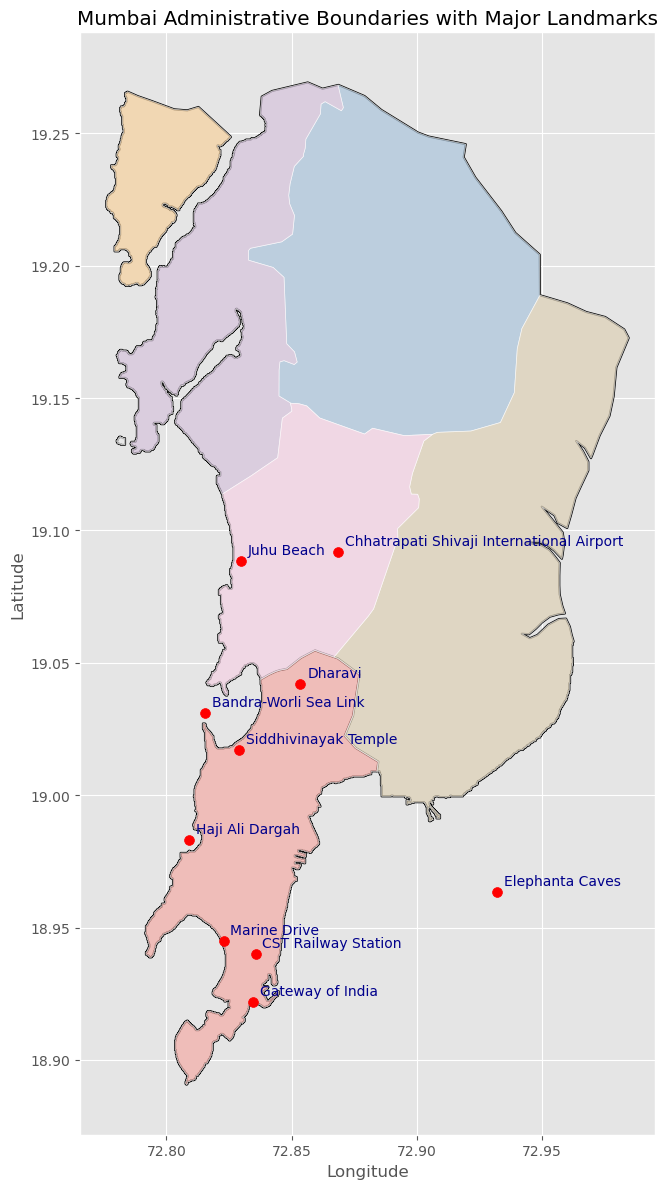

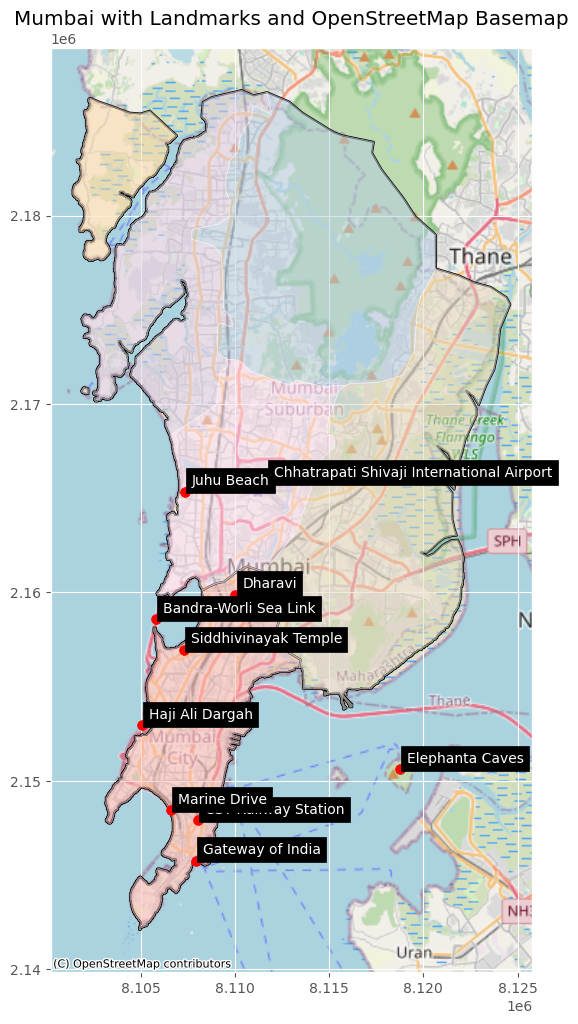


Landmarks and their Wards:
Gateway of India is in W01 (Bombay)
CST Railway Station is in W01 (Bombay)
Bandra-Worli Sea Link is not within any ward boundary
Juhu Beach is in W06 (n.a. ( 1569))
Chhatrapati Shivaji International Airport is in W06 (n.a. ( 1569))
Elephanta Caves is not within any ward boundary
Marine Drive is in W01 (Bombay)
Haji Ali Dargah is not within any ward boundary
Siddhivinayak Temple is in W01 (Bombay)
Dharavi is in W01 (Bombay)


In [5]:
## 4. Add Important Landmarks


# Define important Mumbai landmarks for reference
landmarks = {
    "Gateway of India": (72.8347, 18.9220),
    "CST Railway Station": (72.8356, 18.9402),
    "Bandra-Worli Sea Link": (72.8156, 19.0309),
    "Juhu Beach": (72.8296, 19.0883),
    "Chhatrapati Shivaji International Airport": (72.8685, 19.0919),
    "Elephanta Caves": (72.9319, 18.9633),
    "Marine Drive": (72.8228, 18.9448),
    "Haji Ali Dargah": (72.8090, 18.9830),
    "Siddhivinayak Temple": (72.8289, 19.0170),
    "Dharavi": (72.8535, 19.0420)
}

# Create a GeoDataFrame of landmarks
landmark_points = [Point(lon, lat) for lon, lat in landmarks.values()]
landmark_df = gpd.GeoDataFrame(
    {'name': landmarks.keys(), 'geometry': landmark_points}, 
    crs="EPSG:4326"
)

# Check if boundary files exist
if mumbai_boundary_file.exists() and mumbai_wards_file.exists():
    # Load Mumbai boundary and wards
    mumbai = gpd.read_file(mumbai_boundary_file)
    wards = gpd.read_file(mumbai_wards_file)
    
    # Plot Mumbai with landmarks
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Plot boundary first
    mumbai.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=1.5)
    
    # Plot wards with color
    wards.plot(ax=ax, cmap='Pastel1', edgecolor='white', linewidth=0.5, alpha=0.7)
    
    # Plot landmarks
    landmark_df.plot(ax=ax, color='red', markersize=50)
    
    # Add landmark labels
    for idx, row in landmark_df.iterrows():
        ax.annotate(row['name'], xy=(row.geometry.x, row.geometry.y),
                  xytext=(5, 5), textcoords="offset points",
                  fontsize=10, color='darkblue')
    
    ax.set_title("Mumbai Administrative Boundaries with Major Landmarks")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.savefig(output_dir / "mumbai_with_landmarks.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Plot with basemap
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Convert to Web Mercator for contextily
    mumbai_web = mumbai.to_crs(epsg=3857)
    wards_web = wards.to_crs(epsg=3857)
    landmark_web = landmark_df.to_crs(epsg=3857)
    
    # Plot layers
    mumbai_web.plot(ax=ax, color='none', edgecolor='black', linewidth=1.5)
    wards_web.plot(ax=ax, cmap='Pastel1', edgecolor='white', linewidth=0.5, alpha=0.5)
    landmark_web.plot(ax=ax, color='red', markersize=50)
    
    # Add landmark labels
    for idx, row in landmark_web.iterrows():
        ax.annotate(row['name'], xy=(row.geometry.x, row.geometry.y),
                  xytext=(5, 5), textcoords="offset points",
                  fontsize=10, color='white', backgroundcolor='black')
    
    # Add OpenStreetMap basemap
    try:
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
        plt.title("Mumbai with Landmarks and OpenStreetMap Basemap")
        plt.savefig(output_dir / "mumbai_landmarks_with_basemap.png", dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Error adding basemap: {e}")
    
    # Find which ward each landmark is in
    print("\nLandmarks and their Wards:")
    
    for idx, landmark in landmark_df.iterrows():
        # Find which ward contains this landmark
        containing_ward = None
        for ward_idx, ward in wards.iterrows():
            if ward.geometry.contains(landmark.geometry):
                containing_ward = ward
                break
        
        if containing_ward is not None:
            ward_id = containing_ward['ward_id'] if 'ward_id' in containing_ward else f"Ward {ward_idx+1}"
            ward_name = containing_ward['NAME_3'] if 'NAME_3' in containing_ward else ward_id
            print(f"{landmark['name']} is in {ward_id} ({ward_name})")
        else:
            print(f"{landmark['name']} is not within any ward boundary")




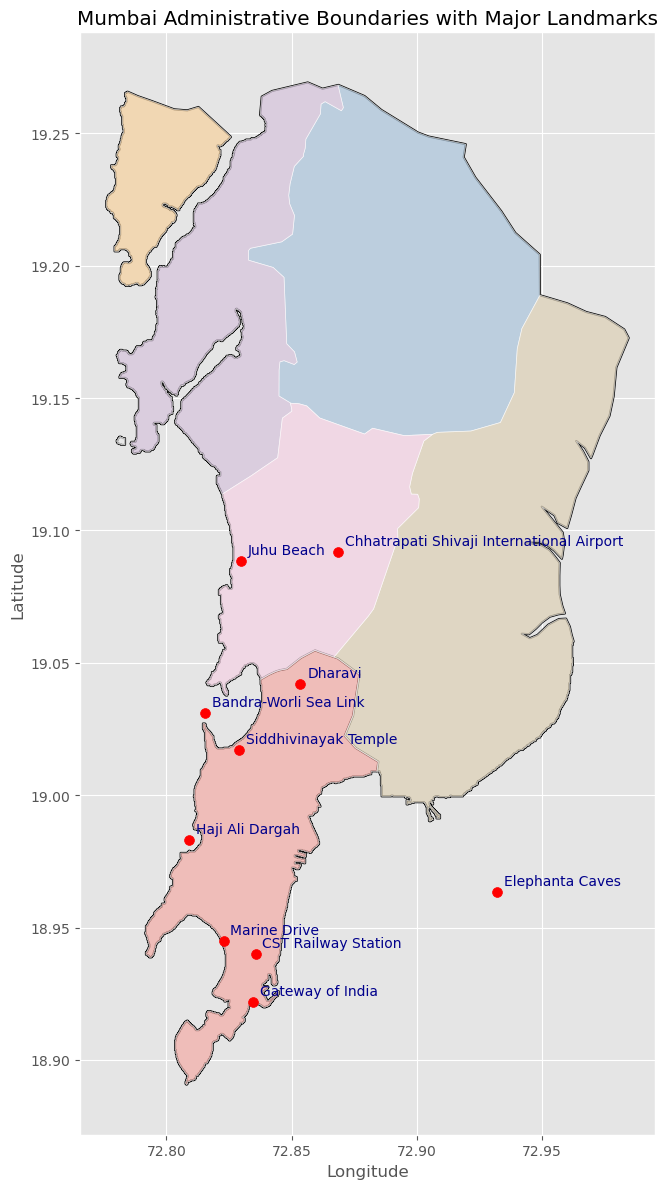

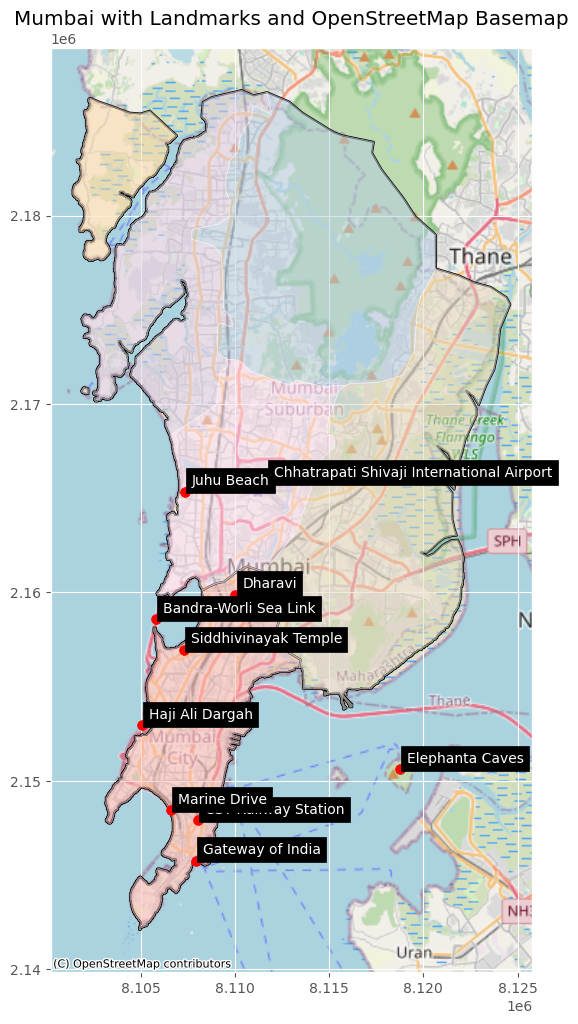


Landmarks and their Wards:
Gateway of India is in W01 (W01)
CST Railway Station is in W01 (W01)
Bandra-Worli Sea Link is not within any ward boundary
Juhu Beach is in W06 (W06)
Chhatrapati Shivaji International Airport is in W06 (W06)
Elephanta Caves is not within any ward boundary
Marine Drive is in W01 (W01)
Haji Ali Dargah is not within any ward boundary
Siddhivinayak Temple is in W01 (W01)
Dharavi is in W01 (W01)


In [6]:
## 5. Add Important Landmarks to the Map

# Define important Mumbai landmarks for reference
landmarks = {
    "Gateway of India": (72.8347, 18.9220),
    "CST Railway Station": (72.8356, 18.9402),
    "Bandra-Worli Sea Link": (72.8156, 19.0309),
    "Juhu Beach": (72.8296, 19.0883),
    "Chhatrapati Shivaji International Airport": (72.8685, 19.0919),
    "Elephanta Caves": (72.9319, 18.9633),
    "Marine Drive": (72.8228, 18.9448),
    "Haji Ali Dargah": (72.8090, 18.9830),
    "Siddhivinayak Temple": (72.8289, 19.0170),
    "Dharavi": (72.8535, 19.0420)
}

# Create a GeoDataFrame of landmarks
landmark_points = [Point(lon, lat) for lon, lat in landmarks.values()]
landmark_df = gpd.GeoDataFrame(
    {'name': landmarks.keys(), 'geometry': landmark_points}, 
    crs="EPSG:4326"
)

# Check if boundary files exist
if mumbai_boundary_file.exists() and mumbai_wards_file.exists() and mumbai is not None and wards is not None:
    # Plot Mumbai with landmarks
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Plot boundary first
    mumbai.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=1.5)
    
    # Plot wards with color
    if 'population' in wards.columns:
        wards.plot(ax=ax, column='population', cmap='YlOrRd', edgecolor='white', 
                  linewidth=0.5, alpha=0.7, legend=True,
                  legend_kwds={'label': "Population"})
    else:
        wards.plot(ax=ax, cmap='Pastel1', edgecolor='white', linewidth=0.5, alpha=0.7)
    
    # Plot landmarks
    landmark_df.plot(ax=ax, color='red', markersize=50)
    
    # Add landmark labels
    for idx, row in landmark_df.iterrows():
        ax.annotate(row['name'], xy=(row.geometry.x, row.geometry.y),
                  xytext=(5, 5), textcoords="offset points",
                  fontsize=10, color='darkblue')
    
    ax.set_title("Mumbai Administrative Boundaries with Major Landmarks")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.savefig(output_dir / "mumbai_with_landmarks.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Plot with basemap
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Convert to Web Mercator for contextily
    mumbai_web = mumbai.to_crs(epsg=3857)
    wards_web = wards.to_crs(epsg=3857)
    landmark_web = landmark_df.to_crs(epsg=3857)
    
    # Plot layers
    mumbai_web.plot(ax=ax, color='none', edgecolor='black', linewidth=1.5)
    
    if 'population' in wards_web.columns:
        wards_web.plot(ax=ax, column='population', cmap='YlOrRd', edgecolor='white', 
                     linewidth=0.5, alpha=0.5, legend=True,
                     legend_kwds={'label': "Population"})
    else:
        wards_web.plot(ax=ax, cmap='Pastel1', edgecolor='white', linewidth=0.5, alpha=0.5)
    
    landmark_web.plot(ax=ax, color='red', markersize=50)
    
    # Add landmark labels
    for idx, row in landmark_web.iterrows():
        ax.annotate(row['name'], xy=(row.geometry.x, row.geometry.y),
                  xytext=(5, 5), textcoords="offset points",
                  fontsize=10, color='white', backgroundcolor='black')
    
    # Add OpenStreetMap basemap
    try:
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
        plt.title("Mumbai with Landmarks and OpenStreetMap Basemap")
        plt.savefig(output_dir / "mumbai_landmarks_with_basemap.png", dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Error adding basemap: {e}")
    
    # Find which ward each landmark is in
    print("\nLandmarks and their Wards:")
    
    for idx, landmark in landmark_df.iterrows():
        # Find which ward contains this landmark
        containing_ward = None
        for ward_idx, ward in wards.iterrows():
            if ward.geometry.contains(landmark.geometry):
                containing_ward = ward
                break
        
        if containing_ward is not None:
            ward_id = containing_ward['ward_id'] if 'ward_id' in containing_ward else f"Ward {ward_idx+1}"
            ward_name = containing_ward.get('census_ward_name', ward_id)
            
            # Add population info if available
            if 'population' in containing_ward:
                population_info = f", Population: {int(containing_ward['population']):,}"
            else:
                population_info = ""
                
            print(f"{landmark['name']} is in {ward_id} ({ward_name}{population_info})")
        else:
            print(f"{landmark['name']} is not within any ward boundary")



In [7]:
## 6. Calculate Ward Statistics for Vulnerability Assessment

# Check if ward file exists
if mumbai_wards_file.exists() and wards is not None:
    # Calculate ward statistics for vulnerability assessment
    print("\nCalculating ward statistics for vulnerability assessment...")
    
    # Select columns for the statistics table
    stat_cols = ['ward_id']
    if 'NAME_3' in wards.columns:
        stat_cols.append('NAME_3')
    if 'census_ward_name' in wards.columns:
        stat_cols.append('census_ward_name')
    stat_cols.append('area_sqkm')
    
    # Add population data if available
    if 'population' in wards.columns:
        stat_cols.extend(['population', 'population_density', 'gender_ratio'])
        if 'sc_percentage' in wards.columns:
            stat_cols.extend(['sc_percentage', 'st_percentage'])
    
    # Create statistic dataframe
    ward_stats = wards[stat_cols].copy()
    
    # Add perimeter and compactness metrics
    wards_utm = wards.to_crs(epsg=32643)  # UTM Zone 43N for accurate measurement
    ward_stats['perimeter_km'] = wards_utm.length / 1000  # Convert from m to km
    
    # Add compactness ratio (area / perimeter²) - higher values mean more compact shapes
    ward_stats['compactness'] = (4 * np.pi * wards_utm.area) / (wards_utm.length ** 2)
    
    # Calculate centroid coordinates
    centroids = wards.centroid
    ward_stats['centroid_lon'] = centroids.x
    ward_stats['centroid_lat'] = centroids.y
    
    # Create a vulnerability index based on available data
    if 'population_density' in ward_stats.columns:
        # Simple example: normalized weighted sum of factors
        # High population density increases vulnerability
        # Low elevation increases vulnerability
        
        # Normalize population density (0-1 scale, higher is more vulnerable)
        min_density = ward_stats['population_density'].min()
        max_density = ward_stats['population_density'].max()
        if max_density > min_density:
            ward_stats['norm_pop_density'] = (ward_stats['population_density'] - min_density) / (max_density - min_density)
        else:
            ward_stats['norm_pop_density'] = 0
        
        # Create vulnerability index with available factors
        # In a real project, you would include elevation, socioeconomic factors, etc.
        ward_stats['vulnerability_index'] = ward_stats['norm_pop_density']
        
        # Plot vulnerability index
        fig, ax = plt.subplots(figsize=(12, 10))
        wards.plot(column='vulnerability_index', ax=ax, legend=True, cmap='YlOrRd',
                  legend_kwds={'label': "Vulnerability Index\n(higher values = more vulnerable)"})
        
        # Add ward labels
        for idx, row in wards.iterrows():
            centroid = row.geometry.centroid
            ax.text(centroid.x, centroid.y, row['ward_id'], fontsize=9, 
                   ha='center', va='center', color='black')
        
        ax.set_title("Mumbai Ward Vulnerability Index (Based on Population Density)")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        plt.savefig(output_dir / "ward_vulnerability_index.png", dpi=300, bbox_inches='tight')
        plt.show()
    
    # Save ward statistics
    stats_file = output_dir / "mumbai_ward_statistics.csv"
    ward_stats.to_csv(stats_file, index=False)
    print(f"Ward statistics saved to {stats_file}")
    
    # Plot compactness - more compact wards may have different flood dynamics
    fig, ax = plt.subplots(figsize=(12, 10))
    wards.plot(column='compactness', ax=ax, legend=True, cmap='viridis',
               legend_kwds={'label': "Compactness\n(higher = more compact)"})
    
    # Add ward labels
    for idx, row in wards.iterrows():
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, row['ward_id'], fontsize=9, 
               ha='center', va='center', color='black')
    
    ax.set_title("Mumbai Ward Compactness")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.savefig(output_dir / "ward_compactness.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Display summary statistics
    print("\nWard Statistics Summary:")
    
    # Select numeric columns for summary
    numeric_cols = ward_stats.select_dtypes(include=['float64', 'int64']).columns
    print(ward_stats[numeric_cols].describe())




Calculating ward statistics for vulnerability assessment...


KeyError: "['area_sqkm'] not in index"

In [ ]:
## 7. Export to Different Formats for Other Applications

# Check if boundary files exist
if mumbai_boundary_file.exists() and mumbai_wards_file.exists() and mumbai is not None and wards is not None:
    # Create export directory
    export_dir = Path("data/processed/boundaries")
    export_dir.mkdir(exist_ok=True, parents=True)
    
    print("\nExporting boundaries to different formats...")
    
    # Export to GeoJSON (for web applications)
    mumbai.to_file(export_dir / "mumbai_boundary.geojson", driver="GeoJSON")
    wards.to_file(export_dir / "mumbai_wards.geojson", driver="GeoJSON")
    print("Exported to GeoJSON format")
    
    # Export to KML (for Google Earth)
    try:
        mumbai.to_file(export_dir / "mumbai_boundary.kml", driver="KML")
        wards.to_file(export_dir / "mumbai_wards.kml", driver="KML")
        print("Exported to KML format")
    except Exception as e:
        print(f"Error exporting to KML: {e}")
    
    # Export to CSV with WKT geometry (for simple applications)
    mumbai['geometry_wkt'] = mumbai.geometry.apply(lambda g: g.wkt)
    wards['geometry_wkt'] = wards.geometry.apply(lambda g: g.wkt)
    
    mumbai_csv = mumbai.drop(columns='geometry')
    wards_csv = wards.drop(columns='geometry')
    
    mumbai_csv.to_csv(export_dir / "mumbai_boundary.csv", index=False)
    wards_csv.to_csv(export_dir / "mumbai_wards.csv", index=False)
    print("Exported to CSV format with WKT geometry")
    
    # Export UTM projected versions (for accurate distance/area calculations)
    mumbai.to_crs(epsg=32643).to_file(export_dir / "mumbai_boundary_utm43n.shp")
    wards.to_crs(epsg=32643).to_file(export_dir / "mumbai_wards_utm43n.shp")
    print("Exported to UTM Zone 43N projection")
    
    print(f"All exports saved to {export_dir}")



## 2. Digital Elevation Model (DEM)

Now let's explore the DEM data:




In [ ]:

# Check if the DEM file exists
dem_file = Path("data/raw/dem/mumbai_dem.tif")
clipped_dem_file = Path("data/processed/hydrology/mumbai_dem_clipped.tif")
dem_path = clipped_dem_file if clipped_dem_file.exists() else dem_file

if dem_path.exists():
    # Open the DEM file
    with rasterio.open(dem_path) as src:
        print(f"CRS: {src.crs}")
        print(f"Dimensions: {src.width} x {src.height}")
        print(f"Resolution: {src.res}")
        print(f"Bounds: {src.bounds}")

        # Read the DEM data
        dem = src.read(1)

        # Handle nodata values
        if src.nodata is not None:
            print(f"Nodata value: {src.nodata}")
            dem = np.where(dem == src.nodata, np.nan, dem)

        # Calculate basic statistics
        print(f"Min elevation: {np.nanmin(dem):.2f} m")
        print(f"Max elevation: {np.nanmax(dem):.2f} m")
        print(f"Mean elevation: {np.nanmean(dem):.2f} m")
        print(f"Standard deviation: {np.nanstd(dem):.2f} m")

        # Plot the DEM
        fig, ax = plt.subplots(figsize=(12, 10))
        img = ax.imshow(dem, cmap='terrain')
        plt.colorbar(img, ax=ax, label='Elevation (m)')
        plt.title("Mumbai Digital Elevation Model")
        plt.show()

        # Plot elevation histogram
        plt.figure(figsize=(10, 6))
        plt.hist(dem[~np.isnan(dem)].flatten(), bins=30, color='skyblue', edgecolor='black')
        plt.title("Elevation Distribution")
        plt.xlabel("Elevation (m)")
        plt.ylabel("Frequency")
        plt.grid(True, alpha=0.3)
        plt.show()

        # If we have the boundary, mask the DEM with it and plot
        boundary_file = Path("data/raw/boundaries/mumbai_wards.shp")
        if boundary_file.exists():
            try:
                boundary = gpd.read_file(boundary_file)
                # Make sure boundary is in the same CRS as raster
                boundary = boundary.to_crs(src.crs)
                # Get geometry as GeoJSON-like dict
                shapes = [mapping(geom) for geom in boundary.geometry]
                # Mask the raster
                out_image, out_transform = mask(src, shapes, crop=True)
                # Plot the masked DEM
                fig, ax = plt.subplots(figsize=(12, 10))
                masked_dem = out_image[0]
                if src.nodata is not None:
                    masked_dem = np.where(masked_dem == src.nodata, np.nan, masked_dem)
                img = ax.imshow(masked_dem, cmap='terrain')
                plt.colorbar(img, ax=ax, label='Elevation (m)')
                plt.title("Mumbai DEM (Masked by Boundary)")
                plt.axis('off')
                plt.show()
            except Exception as e:
                print(f"Error masking DEM with boundary: {e}")
else:
    print("DEM file not found at:", dem_file)
    print("Clipped DEM file not found at:", clipped_dem_file)

```
Define the bounding box for Mumbai (approximate coordinates)

min_lon, min_lat = 72.67494596150834, 18.822731593095607
max_lon, max_lat = 73.09788598906245, 19.4042741309825
```

## 3. Infrastructure Data

Let's examine what infrastructure data we have:




Infrastructure files found: ['mumbai_critical.shp', 'mumbai_roads.shp', 'mumbai_buildings.shp', 'mumbai_water.shp', 'mumbai_drainage.shp']

mumbai_roads.shp:
  CRS: EPSG:4326
  Features: 60208
  Geometry types: ['LineString']
  Columns: ['osm_id', 'name', 'highway', 'waterway', 'aerialway', 'barrier', 'man_made', 'railway', 'z_order', 'other_tags', 'geometry']


NameError: name 'boundary_file' is not defined

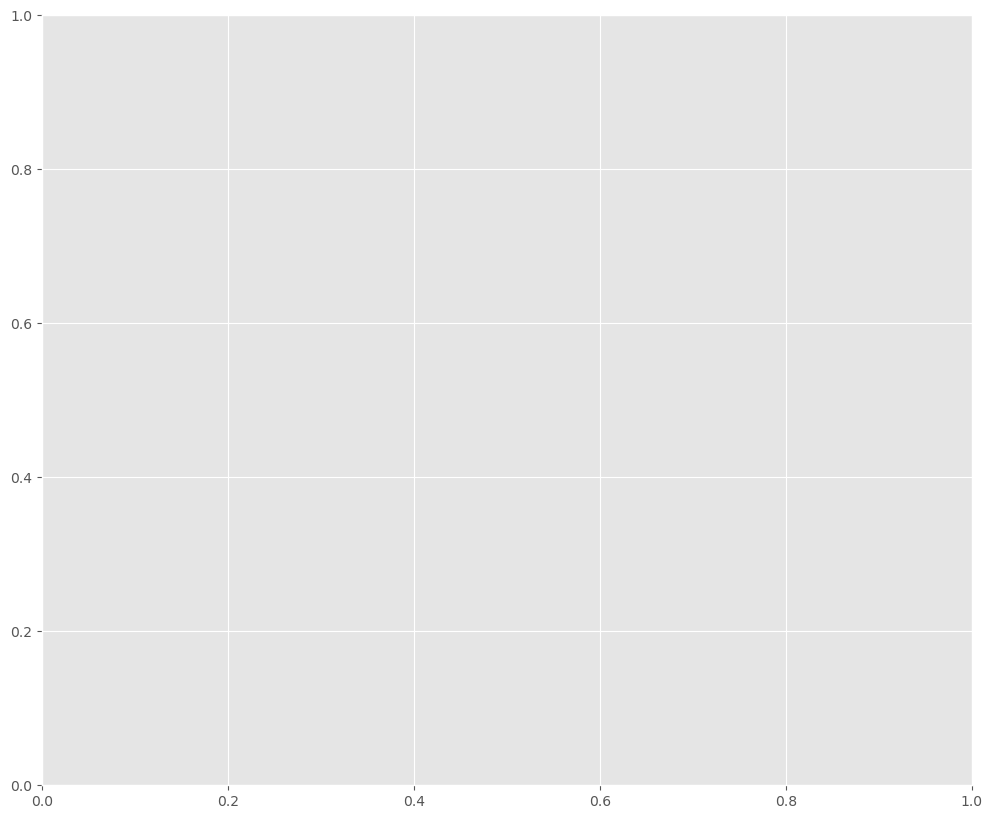

In [8]:
# Check what infrastructure files we have
infra_dir = Path("data/raw/infrastructure")
infra_files = list(infra_dir.glob("*.shp"))

if infra_files:
    print(f"Infrastructure files found: {[f.name for f in infra_files]}")
    
    # Create a function to load and plot each infrastructure layer
    def explore_infra_layer(file_name, color='blue', alpha=0.7, title=None):
        file_path = infra_dir / file_name
        if file_path.exists():
            # Load the data
            data = gpd.read_file(file_path)
            print(f"\n{file_name}:")
            print(f"  CRS: {data.crs}")
            print(f"  Features: {len(data)}")
            print(f"  Geometry types: {data.geometry.geom_type.unique()}")
            print(f"  Columns: {data.columns.tolist()}")
            
            # Plot the data
            fig, ax = plt.subplots(figsize=(12, 10))
            
            # If we have a boundary, plot it first
            if boundary_file.exists():
                boundary = gpd.read_file(boundary_file)
                boundary.plot(ax=ax, color='lightgrey', edgecolor='black')
            
            # Plot the infrastructure data
            data.plot(ax=ax, color=color, alpha=alpha)
            plt.title(title or f"Mumbai {file_name}")
            plt.xlabel("Longitude")
            plt.ylabel("Latitude")
            plt.show()
            
            return data
        else:
            print(f"{file_name} not found")
            return None
    
    # Explore each infrastructure layer
    if (infra_dir / "mumbai_roads.shp").exists():
        roads = explore_infra_layer("mumbai_roads.shp", color='black', alpha=0.5, title="Mumbai Road Network")
    
    if (infra_dir / "mumbai_water.shp").exists():
        water = explore_infra_layer("mumbai_water.shp", color='blue', alpha=0.6, title="Mumbai Water Bodies")
    
    if (infra_dir / "mumbai_drainage.shp").exists():
        drainage = explore_infra_layer("mumbai_drainage.shp", color='cyan', alpha=0.8, title="Mumbai Drainage Network")
    
    if (infra_dir / "mumbai_buildings.shp").exists():
        buildings = explore_infra_layer("mumbai_buildings.shp", color='red', alpha=0.5, title="Mumbai Buildings")
    
    if (infra_dir / "mumbai_critical.shp").exists():
        critical = explore_infra_layer("mumbai_critical.shp", color='purple', alpha=1.0, title="Mumbai Critical Infrastructure")
        
        # If we have amenity information, show the distribution
        if critical is not None and 'amenity' in critical.columns:
            plt.figure(figsize=(10, 6))
            critical['amenity'].value_counts().plot(kind='bar', color='purple')
            plt.title("Types of Critical Infrastructure")
            plt.xlabel("Amenity Type")
            plt.ylabel("Count")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
    
    # Create a composite map with multiple infrastructure layers
    if len(infra_files) > 1:
        fig, ax = plt.subplots(figsize=(14, 12))
        
        # Plot boundary first if it exists
        if boundary_file.exists():
            boundary = gpd.read_file(boundary_file)
            boundary.plot(ax=ax, color='lightgrey', edgecolor='black')
        
        # Plot infrastructure layers with different colors and transparency
        if (infra_dir / "mumbai_water.shp").exists():
            gpd.read_file(infra_dir / "mumbai_water.shp").plot(ax=ax, color='blue', alpha=0.6)
        
        if (infra_dir / "mumbai_drainage.shp").exists():
            gpd.read_file(infra_dir / "mumbai_drainage.shp").plot(ax=ax, color='cyan', alpha=0.7)
        
        if (infra_dir / "mumbai_roads.shp").exists():
            gpd.read_file(infra_dir / "mumbai_roads.shp").plot(ax=ax, color='black', alpha=0.5)
        
        if (infra_dir / "mumbai_buildings.shp").exists():
            gpd.read_file(infra_dir / "mumbai_buildings.shp").plot(ax=ax, color='red', alpha=0.3)
        
        if (infra_dir / "mumbai_critical.shp").exists():
            gpd.read_file(infra_dir / "mumbai_critical.shp").plot(ax=ax, color='purple', alpha=1.0, markersize=30)
        
        plt.title("Mumbai Infrastructure Composite Map")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.show()
else:
    print("No infrastructure files found in:", infra_dir)




## 4. Preliminary Flood Vulnerability Assessment

Using what we have so far, let's perform a simple elevation-based vulnerability assessment:




In [ ]:
# Check if we have DEM and boundary data to perform a basic assessment
if dem_path.exists() and boundary_file.exists():
    try:
        print("Performing preliminary elevation-based vulnerability assessment...")
        
        # Load boundary
        boundary = gpd.read_file(boundary_file)
        
        # Determine if we have ward boundaries for zonal stats
        ward_level = False
        if mumbai_boundary_file.exists():
            wards = gpd.read_file(mumbai_boundary_file)
            if 'ward_id' in wards.columns:
                ward_level = True
        
        # Open the DEM
        with rasterio.open(dem_path) as src:
            dem = src.read(1)
            transform = src.transform
            
            # Handle nodata values
            if src.nodata is not None:
                dem = np.where(dem == src.nodata, np.nan, dem)
            
            # Create a simple vulnerability classification based on elevation
            # Low elevation = high vulnerability to flooding
            elevation_thresholds = [5, 10, 20, 50]
            vulnerability_classes = [5, 4, 3, 2, 1]  # 5 = highest vulnerability
            
            vuln_dem = np.zeros_like(dem)
            vuln_dem[:] = np.nan
            
            # Classify each pixel based on elevation
            vuln_dem[dem <= elevation_thresholds[0]] = vulnerability_classes[0]
            for i in range(1, len(elevation_thresholds)):
                vuln_dem[(dem > elevation_thresholds[i-1]) & (dem <= elevation_thresholds[i])] = vulnerability_classes[i]
            vuln_dem[dem > elevation_thresholds[-1]] = vulnerability_classes[-1]
            
            # Plot the vulnerability map
            fig, ax = plt.subplots(figsize=(12, 10))
            cmap = plt.cm.get_cmap('YlOrRd', 5)
            img = ax.imshow(vuln_dem, cmap=cmap)
            cbar = plt.colorbar(img, ax=ax, ticks=range(1, 6))
            cbar.set_label('Vulnerability Level')
            cbar.set_ticklabels(['Very Low', 'Low', 'Medium', 'High', 'Very High'])
            plt.title("Preliminary Elevation-Based Flood Vulnerability")
            plt.axis('off')
            plt.show()
            
            # Calculate vulnerable area percentages
            valid_pixels = np.sum(~np.isnan(vuln_dem))
            vulnerability_distribution = []
            
            for i, level in enumerate(vulnerability_classes):
                level_name = ['Very High', 'High', 'Medium', 'Low', 'Very Low'][i]
                pixel_count = np.sum(vuln_dem == level)
                percentage = (pixel_count / valid_pixels) * 100 if valid_pixels > 0 else 0
                vulnerability_distribution.append({
                    'Level': level_name,
                    'Pixels': pixel_count,
                    'Percentage': percentage
                })
            
            # Create a DataFrame and display
            vuln_df = pd.DataFrame(vulnerability_distribution)
            print("\nVulnerability Distribution:")
            print(vuln_df)
            
            # Plot vulnerability distribution
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Level', y='Percentage', data=vuln_df, 
                       palette=sns.color_palette('YlOrRd_r', 5))
            plt.title("Flood Vulnerability Distribution")
            plt.xlabel("Vulnerability Level")
            plt.ylabel("Percentage of Area")
            plt.show()
            
            # If we have ward boundaries, calculate ward-level statistics
            if ward_level:
                print("\nCalculating ward-level vulnerability statistics...")
                
                # Use zonal statistics to calculate mean vulnerability for each ward
                import rasterstats
                
                # Make sure wards are in same CRS as raster
                wards = wards.to_crs(src.crs)
                
                # Calculate zonal statistics
                zs = rasterstats.zonal_stats(wards, vuln_dem, affine=transform, stats=['mean', 'min', 'max'],
                                           nodata=np.nan)
                
                # Create a DataFrame
                ward_vuln = pd.DataFrame(zs)
                ward_vuln['ward_id'] = wards['ward_id']
                
                # Sort by mean vulnerability (descending)
                ward_vuln = ward_vuln.sort_values('mean', ascending=False)
                
                print("Ward-level vulnerability statistics:")
                print(ward_vuln)
                
                # Plot ward-level vulnerability
                fig, ax = plt.subplots(figsize=(12, 10))
                merged = wards.merge(ward_vuln, on='ward_id')
                merged.plot(column='mean', cmap='YlOrRd', linewidth=0.8, ax=ax, 
                           edgecolor='black', legend=True, 
                           legend_kwds={'label': 'Mean Vulnerability'})
                plt.title("Ward-Level Flood Vulnerability")
                plt.xlabel("Longitude")
                plt.ylabel("Latitude")
                plt.show()
                
                # Bar chart of ward vulnerabilities
                plt.figure(figsize=(12, 6))
                sns.barplot(x='ward_id', y='mean', data=ward_vuln)
                plt.title("Mean Flood Vulnerability by Ward")
                plt.xlabel("Ward ID")
                plt.ylabel("Mean Vulnerability Score")
                plt.xticks(rotation=90)
                plt.tight_layout()
                plt.show()
                
    except Exception as e:
        print(f"Error performing preliminary vulnerability assessment: {e}")
else:
    print("Cannot perform vulnerability assessment: Missing DEM or boundary data")




## 5. Data Gaps and Next Steps

Let's identify what's missing and what should be collected next:




In [ ]:
print("Data Collection Status and Gaps:")

# Check for each required dataset
data_status = {
    "Administrative Boundaries": boundary_file.exists(),
    "Ward Boundaries": mumbai_boundary_file.exists(),
    "Digital Elevation Model": dem_path.exists(),
    "Road Network": (infra_dir / "mumbai_roads.shp").exists(),
    "Water Bodies": (infra_dir / "mumbai_water.shp").exists(),
    "Drainage Network": (infra_dir / "mumbai_drainage.shp").exists(),
    "Critical Infrastructure": (infra_dir / "mumbai_critical.shp").exists(),
    "Census Data": Path("data/raw/census/mumbai_ward_census.csv").exists(),
    "Rainfall Data": Path("data/raw/rainfall/mumbai_rainfall.csv").exists(),
}

# Create a DataFrame and display
status_df = pd.DataFrame({
    'Dataset': list(data_status.keys()),
    'Status': ['Available' if status else 'Missing' for status in data_status.values()]
})

print(status_df)



In [ ]:
# Plot data availability
plt.figure(figsize=(10, 6))
colors = ['green' if status else 'red' for status in data_status.values()]
plt.barh(status_df['Dataset'], [1] * len(status_df), color=colors)
plt.title("Data Availability Status")
plt.xlabel("Status")
plt.xlim(0, 1.5)
for i, status in enumerate(status_df['Status']):
    plt.text(1.1, i, status, va='center')
plt.tight_layout()
plt.show()



In [ ]:
# Next steps
print("\nRecommended Next Steps:")
for dataset, available in data_status.items():
    if not available:
        print(f"- Collect {dataset} data")

print("\nFor available data, the next steps are:")
print("1. Continue data preprocessing and cleaning")
print("2. Develop hydrological model components")
print("3. Integrate socioeconomic vulnerability data if census data is available")
print("4. Create composite vulnerability index")




In [ ]:
## 6. Conclusions and Recommendations


print("Initial Data Exploration Conclusions:")
print("1. Data collection status: Some key datasets have been successfully acquired.")
print("2. The available data allows for preliminary analysis but more datasets are needed for a comprehensive assessment.")
print("3. A basic elevation-based vulnerability assessment shows areas potentially at risk from flooding.")

print("\nRecommendations:")
print("1. Continue data collection for missing datasets")
print("2. Perform more detailed preprocessing of existing data")
print("3. Develop hydrological modeling components")
print("4. Begin integration of physical and socioeconomic vulnerability factors")
print("5. Set up the web dashboard framework for visualizing results")




This notebook provides an initial exploration of the data collected so far and identifies gaps that need to be filled to complete the Mumbai Flood Vulnerability Assessment System.

In [ ]:
df = pd.read_csv('data/raw/census/mumbai-census.csv')
df.head()